In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

# Paper reproduction


In [2]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.plot_style import use_house_style

from src.benchmark_analysis import (ETA_B_OBS, benchmark_summary, epsilon_matrix,
    scan_paper_fig1, plot_paper_fig1,
    scan_paper_fig1_with_scattering, plot_paper_fig1_scattering_split,
    scan_i2, plot_i2, plot_i2_side_by_side,plot_i2_scattering)
from utils.koichi_benchmarks import (PAPER_FIG1_REAL, KOICHI_EPS_TAUTAU_ZERO,
    KOICHI_DIAGONAL_ZERO, KOICHI_EXPECTED_EPSILON_DIAGONAL)
use_house_style(dpi=120)

# 1. Relevant plots from arXiv:2107.02079

The four panels use $m_1=0.0159$ eV and $M_3=5M_2=50M_1$. Top/bottom correspond to $(x_1,x_2,x_3)=(-10,-20,-10)^\circ$ and $(+10,+20,+10)^\circ$; left/right correspond to $y_3=30^\circ$ and $y_3=0$. This cell intentionally contains **no scattering**, because scattering is not part of the paper's Fig. 1.

164/164  panel=('bottom', 'right'), M1=1.00e+14


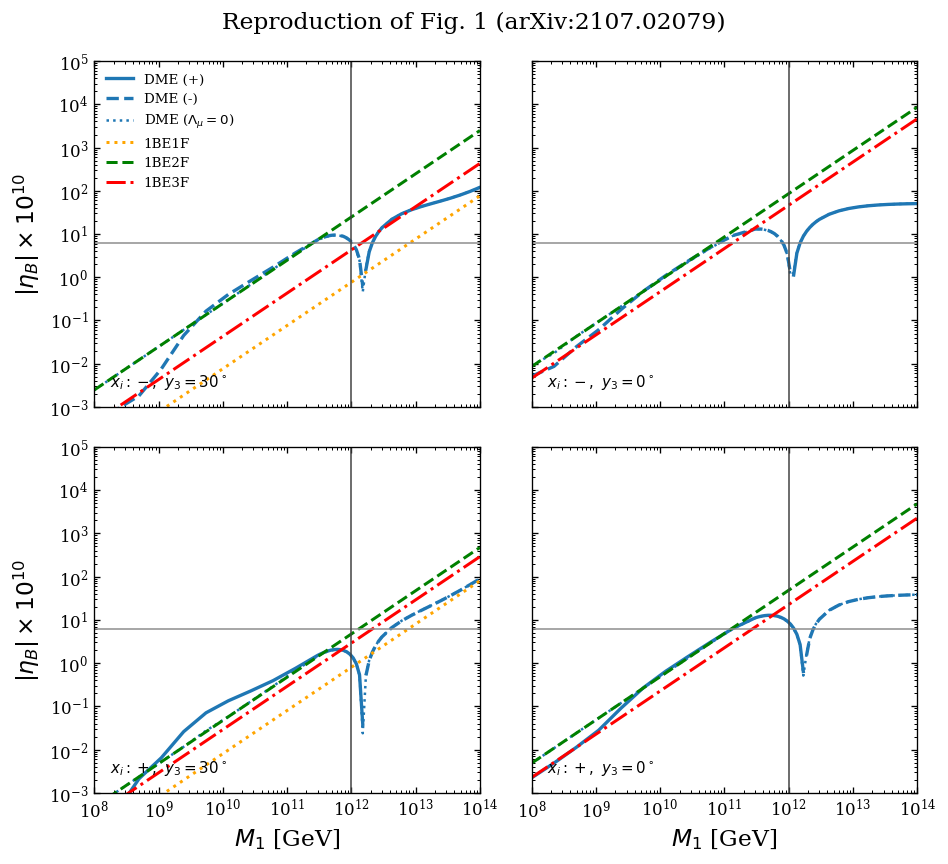

In [3]:
# Extra resolution around 10^12 GeV is needed to resolve the sign-changing dips.
M1_paper = np.unique(np.r_[np.geomspace(1e8, 3e11, 11),
                           np.geomspace(3e11, 3e12, 21),
                           np.geomspace(3e12, 1e14, 11)])
paper_fig1 = scan_paper_fig1(PAPER_FIG1_REAL, M1_paper)
fig, axes = plot_paper_fig1(paper_fig1)
plt.show()

## Fig. 2: $I_2$ and its sign with scattering

The implementation integrates Eqs. (49), (57), (59), and (61) as a coupled system. For the scattering extension, $D+S_s+S_t$ controls $N_1$ equilibration and the corrected washout controls coherence; the CP-odd source still contains $D$ only. This is distinct from simply plotting the positive quantity $2S_s+4S_t$.

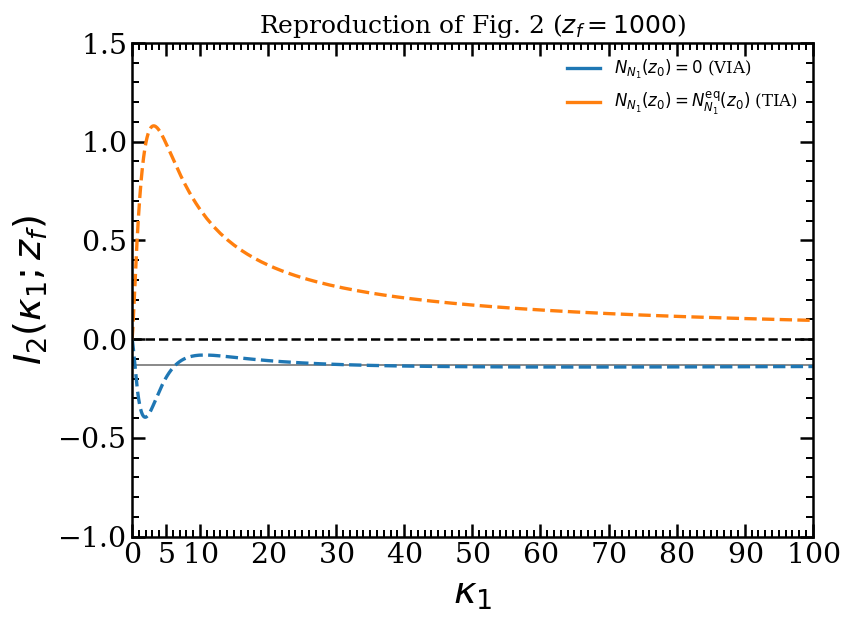

Strong-washout check at kappa=100: I2(VIA)=-0.139, I2(TIA)=0.095


In [4]:
# Compute the original and scattering extensions on the same kappa grid.
kappa_values = np.unique(np.r_[
    np.linspace(0.0, 3.0, 151),   # More points near the sign change
    np.linspace(3.0, 10.0, 71),
    np.linspace(11.0, 100.0, 90),
])

i2 = scan_i2(kappa_values=kappa_values)

# Plot the original Fig. 2 result.
fig, ax = plot_i2(i2)

# Use dashed lines for the two curves without scattering.
# The remaining horizontal reference lines are left unchanged.
for line in ax.lines[:2]:
    line.set_linestyle("--")

plt.show()

print(
    f"Strong-washout check at kappa={i2.kappa1[-1]:.0f}: "
    f"I2(VIA)={i2.vanilla_via[-1]:.3f}, "
    f"I2(TIA)={i2.vanilla_tia[-1]:.3f}"
)

# 2.In the Aug. 20 to-do list

## 2.1 Same real-CI benchmark: BAU with/without scattering

We keep the complete four-panel structure of the reproduced Fig. 1 and add a scattering partner to every displayed option: DME, the auxiliary DME with $\Lambda_\mu=0$, 1BE1F, 1BE2F and 1BE3F. In every panel and for every method, **dashed means the reproduced calculation without scattering** and **solid means with $\Delta L=1$ scattering**.

100/100  panel=('bottom', 'right'), M1=1.00e+14


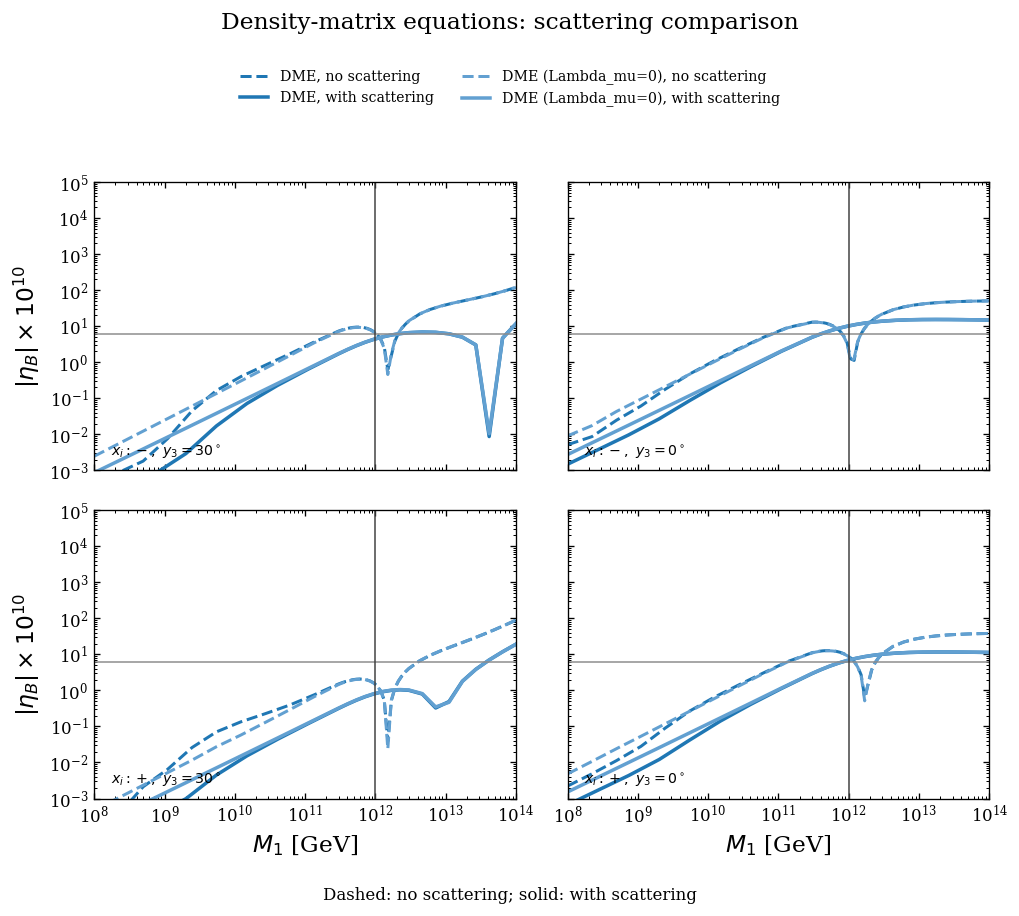

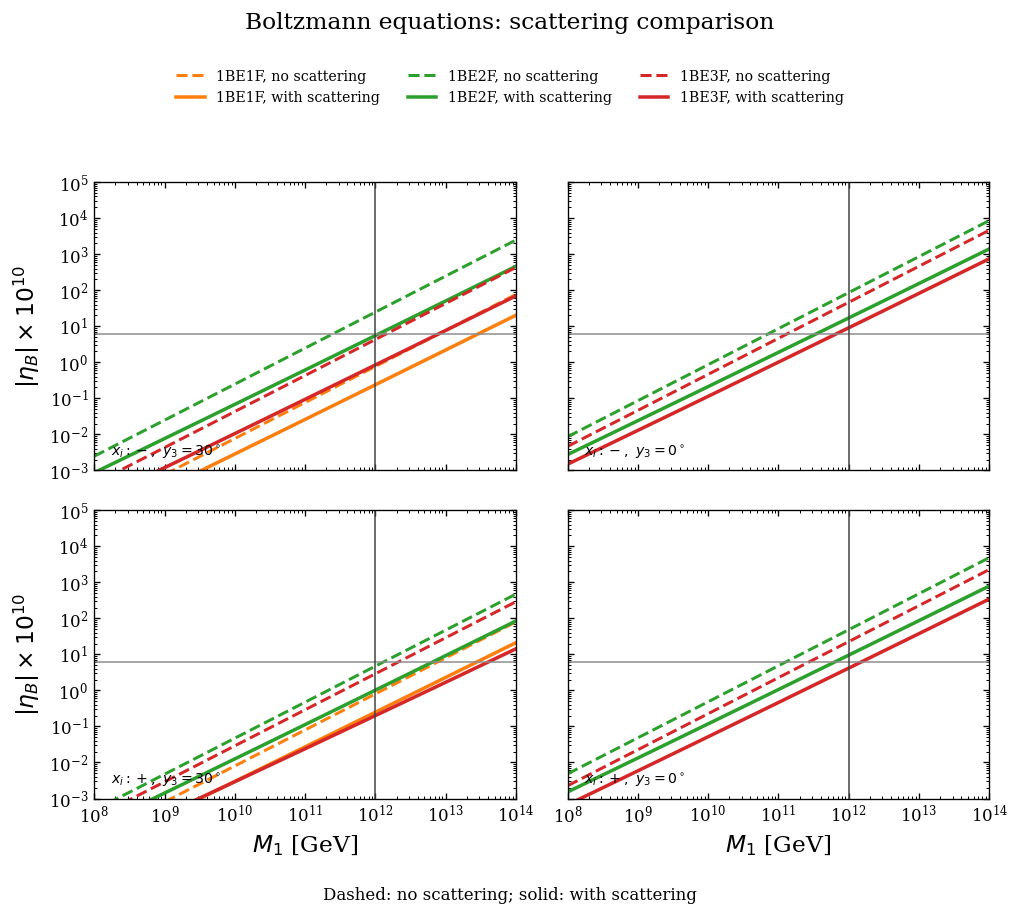

In [ ]:
# Reuse paper_fig1: only the scattering curves are computed in this cell.
# The saved work allows a denser grid around the flavour transition.
M1_scattering = np.unique(np.r_[np.geomspace(1e8, 3e11, 9),
                                  np.geomspace(3e11, 3e12, 9),
                                  np.geomspace(3e12, 1e14, 9)])
fig1_scattering = scan_paper_fig1_with_scattering(
    PAPER_FIG1_REAL, M1_scattering, baseline_scans=paper_fig1)
(fig_dme, axes_dme), (fig_be, axes_be) = (
    plot_paper_fig1_scattering_split(fig1_scattering))
plt.show()
# Signed numerical values for the real-CI (bottom-right) benchmark.
bottom_right = fig1_scattering[('bottom', 'right')]
bau_comparison = pd.DataFrame({'M1 [GeV]': bottom_right['M1_sct']})
for method in ('DME', 'DME (Lambda_mu=0)', '1BE1F', '1BE2F', '1BE3F'):
    baseline_at_sct_grid = np.interp(
        np.log10(bottom_right['M1_sct']),
        np.log10(bottom_right['M1_no_sct']), bottom_right[method])
    bau_comparison[f'{method}, no sct'] = baseline_at_sct_grid
    bau_comparison[f'{method}, +sct'] = bottom_right[f'{method}+sct']
    bau_comparison[f'{method}, |sct/plain|'] = np.abs(
        bottom_right[f'{method}+sct'] / baseline_at_sct_grid)

## 2.2 Extension of Fig. 2: sign of $I_2$ with scattering

Only after validating the original Fig. 2 do we add the repository's $\Delta L=1$ scattering prescription. As in 1-a, dashed curves are the original calculation without scattering and solid curves include scattering. The strong-washout signs and the non-trivial VIA zero are reported numerically below.

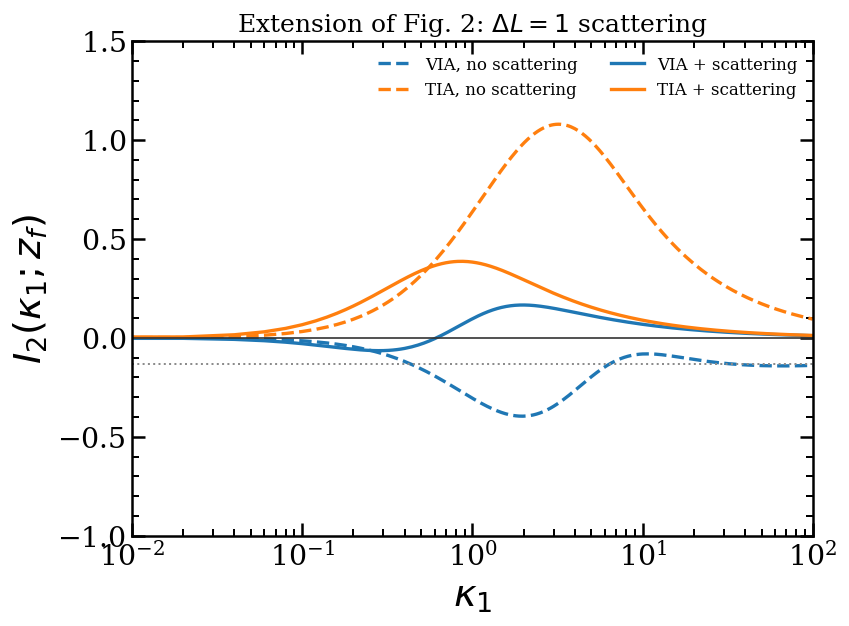

,initial abundance,I2 without scattering,I2 with scattering,sign changed?
0,VIA,-0.138884,0.011209,True
1,TIA,0.094885,0.012376,False


Non-trivial VIA zero(s) with scattering: [0.6139304916906078]
At kappa1=100: VIA -0.13888 -> +0.01121 with scattering; TIA +0.09489 -> +0.01238.


In [6]:
# Reuse the i2 object from the paper-reproduction section: no new scan.
# Dashed lines: without scattering.
# Solid lines: with scattering.

fig, ax = plot_i2_scattering(i2)

ax.set_xscale("log")
ax.set_xlim(1e-2, 1e2)

plt.show()

i2_signs = pd.DataFrame({
    "initial abundance": ["VIA", "TIA"],
    "I2 without scattering": [
        i2.vanilla_via[-1],
        i2.vanilla_tia[-1],
    ],
    "I2 with scattering": [
        i2.scattering_via[-1],
        i2.scattering_tia[-1],
    ],
})

i2_signs["sign changed?"] = (
    np.sign(i2_signs["I2 without scattering"])
    != np.sign(i2_signs["I2 with scattering"])
)

display(i2_signs)

# Locate genuine VIA sign changes.
# Exclude the trivial I2=0 point at kappa1=0.
x = i2.kappa1
y = i2.scattering_via

crossing_indices = np.where(y[:-1] * y[1:] < 0)[0]
via_zeros = []

for j in crossing_indices:
    # Linear interpolation on the dense low-kappa grid.
    zero = (
        x[j]
        - y[j] * (x[j + 1] - x[j])
        / (y[j + 1] - y[j])
    )
    via_zeros.append(zero)

print("Non-trivial VIA zero(s) with scattering:", via_zeros)

print(
    f"At kappa1={x[-1]:.0f}: "
    f"VIA {i2.vanilla_via[-1]:+.5f} -> "
    f"{i2.scattering_via[-1]:+.5f} with scattering; "
    f"TIA {i2.vanilla_tia[-1]:+.5f} -> "
    f"{i2.scattering_tia[-1]:+.5f}."
)

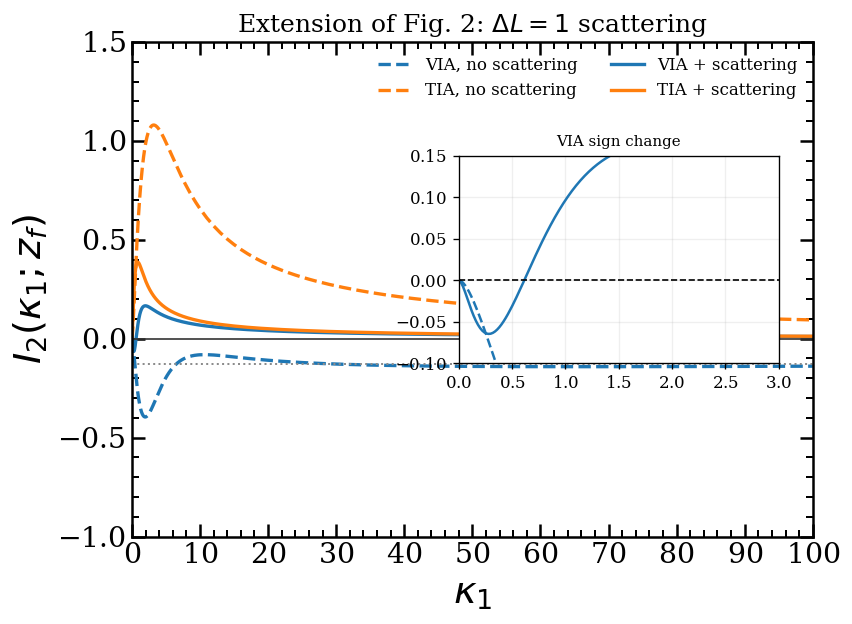

In [7]:
fig, ax = plot_i2_scattering(i2)



axins = ax.inset_axes([0.48, 0.35, 0.47, 0.42])

axins.plot(
    i2.kappa1,
    i2.vanilla_via,
    color="tab:blue",
    linestyle="--",
)

axins.plot(
    i2.kappa1,
    i2.scattering_via,
    color="tab:blue",
    linestyle="-",
)

axins.axhline(0, color="black", linestyle="--", linewidth=1)

axins.set_xlim(0, 3)
axins.set_ylim(-0.1, 0.15)
axins.set_title("VIA sign change", fontsize=9)
axins.grid(alpha=0.2)

plt.show()

## 2.3 Cross-check $\epsilon_{\alpha\beta}$

We compute every matrix entry from ULYSSES rather than copying the note. The residual columns make convention or rounded-input disagreements visible instead of silently declaring agreement. Flavour order is $(e,\mu,\tau)$.

In [ ]:
eps4 = epsilon_matrix(KOICHI_EPS_TAUTAU_ZERO)
eps5 = epsilon_matrix(KOICHI_DIAGONAL_ZERO)
display(pd.DataFrame(eps4, index=['e','mu','tau'], columns=['e','mu','tau']))
crosscheck = pd.DataFrame({
    'flavour': ['e','mu','tau'],
    'note Sec. 4': KOICHI_EXPECTED_EPSILON_DIAGONAL,
    'ULYSSES Sec. 4': np.real(np.diag(eps4)),
    'residual': np.real(np.diag(eps4))-KOICHI_EXPECTED_EPSILON_DIAGONAL,
    'ULYSSES Sec. 5 diagonal': np.real(np.diag(eps5)),
})
display(crosscheck)
print('Sec. 4 trace =', np.trace(eps4), '; Hermiticity residual =', np.max(np.abs(eps4-eps4.conj().T)))
print('Sec. 5 trace =', np.trace(eps5), '; max diagonal =', np.max(np.abs(np.diag(eps5))))

A vanishing trace is expected for a real CI matrix and is a useful invariant check. Vanishing individual diagonals are stronger, parameter-dependent conditions. If the last printed Sec. 5 number is not near numerical precision, the rounded angles/transcription and the loop-function convention in the note must be reconciled before interpreting its BAU as the exact diagonal-zero solution.

## 2.4 BAU at the two note benchmarks

In [ ]:
rows = []
for label, point in [('epsilon_tau,tau = 0', KOICHI_EPS_TAUTAU_ZERO),
                     ('claimed diagonal = 0', KOICHI_DIAGONAL_ZERO)]:
    no_sct = benchmark_summary(point, scattering=False)
    with_sct = benchmark_summary(point, scattering=True)
    rows.append({'benchmark': label, 'kappa1': no_sct['kappa1'],
                 'eta_B': no_sct['eta_B'], 'eta_B + sct': with_sct['eta_B'],
                 '|sct/plain|': abs(with_sct['eta_B']/no_sct['eta_B'])})
pd.DataFrame(rows)

,benchmark,kappa1,eta_B,eta_B + sct,|sct/plain|
0,"epsilon_tau,tau = 0",11.620186,-5.235885e-14,-3.117215e-14,0.595356
1,claimed diagonal = 0,31.576461,1.636280e-14,2.148167e-14,1.312836


## Interpretation

A scattering-induced change in the sign of $I_2$ is evidence that modified production/washout history can reverse the coherence contribution. It is not, by itself, proof that every BAU sign flip is caused exclusively by coherence: the signed DME scan and the CP-asymmetry consistency checks must be considered together.